In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from solar_iot_simulator import (
    SolarIoTConfig,
    run_full_simulation,
    build_design_space,
    load_irradiance_data,
    compute_pv_power,
    compute_hourly_balance,
    simulate_battery_soc,
    evaluate_viability,
    compute_optimal_score
)

## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability and compute scores

In [12]:
# Run the full simulation
results = run_full_simulation("raw-data/CR.csv")

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Evaluating viability...
Computing optimal scores...
Computing optimal scores...
Done!
Done!


## Explore Results

In [13]:
# Display top configurations
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_mAh,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_mAh,deficit_mAh,autonomy_hours,failure_hours,soc_min_fraction,soc_full_fraction,net_mAh,score
0,0.00400,1000,0.98,8760,0,2150,0.899797,0.114043,226770.936965,64886.200390,8760,0,0.0,0.245434,161884.736575,1.000000
1,0.00800,500,0.98,8760,0,3099,0.871833,0.134571,504563.539124,62415.687597,8760,0,0.0,0.353767,442147.851528,0.995893
2,0.00800,500,0.95,8760,0,3072,0.870413,0.135947,487485.682104,62496.796798,8760,0,0.0,0.350685,424988.885306,0.995893
3,0.00400,1300,0.87,8760,0,1915,0.893673,0.128846,195921.440940,65494.809105,8760,0,0.0,0.218607,130426.631835,0.967868
4,0.00400,1300,0.98,8760,0,2150,0.922921,0.087725,226770.936965,64886.200390,8760,0,0.0,0.245434,161884.736575,0.967868
5,0.00400,1300,0.95,8760,0,2090,0.918548,0.094119,218342.315151,65037.061687,8760,0,0.0,0.238584,153305.253464,0.967868
6,0.00400,1300,0.90,8760,0,1976,0.906203,0.111396,204319.706970,65313.592024,8760,0,0.0,0.225571,139006.114946,0.967868
7,0.00625,1000,0.98,8760,0,2827,0.929810,0.074332,382650.755511,63118.016776,8760,0,0.0,0.322717,319532.738736,0.967566
8,0.00625,1000,0.95,8760,0,2783,0.928847,0.075488,369344.505535,63217.209160,8760,0,0.0,0.317694,306127.296375,0.967566
9,0.00625,1000,0.90,8760,0,2715,0.927067,0.077714,347184.656673,63399.764232,8760,0,0.0,0.309932,283784.892441,0.967566


In [14]:
# Display best configuration(s)
best_configs = summary[summary["score"] == summary['score'].max()]
print(f"\nFound {len(best_configs)} optimal configuration(s):")
for _, row in best_configs.iterrows():
    print(f"\nPanel area: {row['panel_area_m2']*10000:.2f} cm²")
    print(f"Battery capacity: {row['C_batt_mAh']} mAh")
    print(f"PMU efficiency: {row['eta_PMU']:.2%}")
    print(f"Score: {row['score']:.4f}")
    print(f"Autonomy: {row['autonomy_hours']} hours")
    print(f"Mean SoC: {row['soc_mean']:.2%}")
    print(f"Failure hours: {row['failure_hours']}")


Found 1 optimal configuration(s):

Panel area: 40.00 cm²
Battery capacity: 1000.0 mAh
PMU efficiency: 98.00%
Score: 1.0000
Autonomy: 8760.0 hours
Mean SoC: 89.98%
Failure hours: 0.0


## Visualization: 3D Scatter Plot

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [15]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_mAh",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_mAh": "Battery (mAh)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## 2D Analysis: Maximum PMU Efficiency Plane

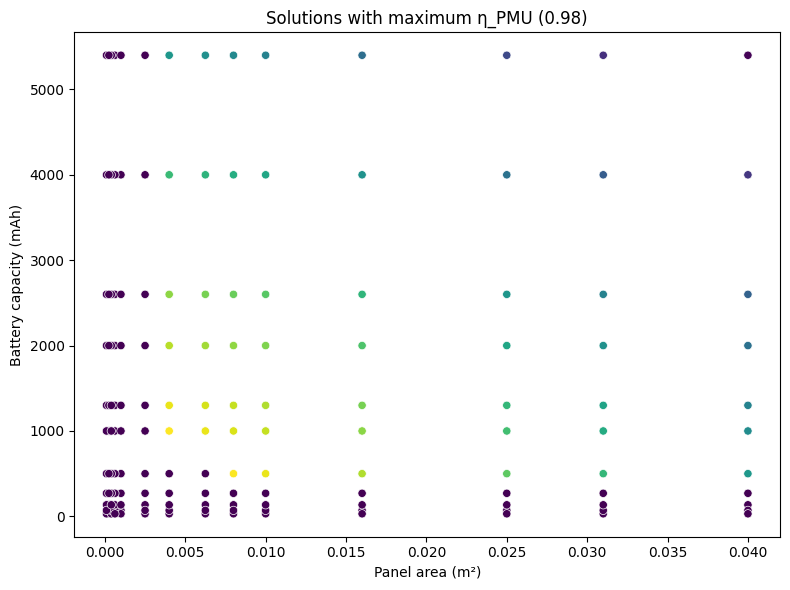

In [16]:
eta_max = summary['eta_PMU'].max()
df_plane = summary[summary['eta_PMU'] == eta_max]

plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df_plane,
    x='panel_area_m2',
    y='C_batt_mAh',
    hue='score',
    palette='viridis'
)

ax.get_legend().remove()

plt.title(f"Solutions with maximum η_PMU ({eta_max})")
plt.xlabel("Panel area (m²)")
plt.ylabel("Battery capacity (mAh)")
plt.tight_layout()
plt.show()

## Score Distribution Histogram

In [17]:
fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()

## 3D Surface Plot: Score at Maximum PMU Efficiency

In [18]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_mAh",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (mAh)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Custom Analysis

You can also access individual simulation steps for custom analysis:

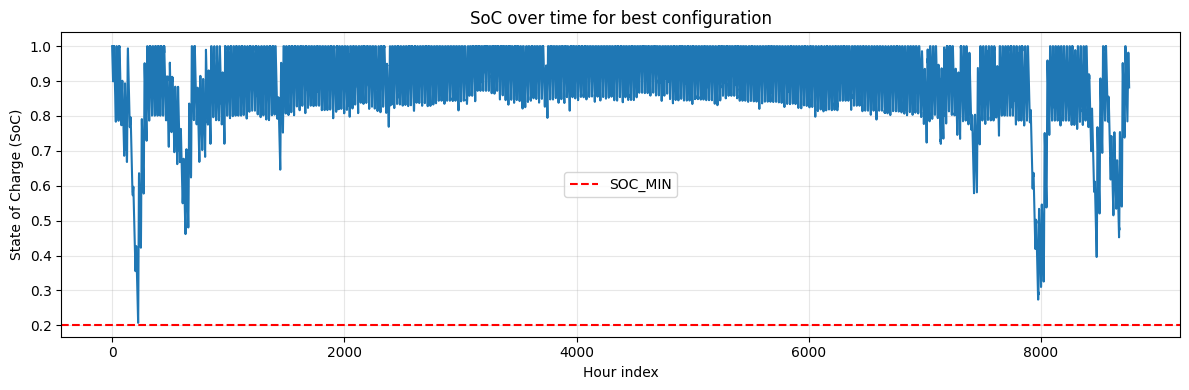

In [19]:
# Example: Analyze a specific configuration's SoC over time
best = best_configs.iloc[0]

# Filter df_soc for this specific configuration
config_soc = df_soc[
    (df_soc['panel_area_m2'] == best['panel_area_m2']) &
    (df_soc['C_batt_mAh'] == best['C_batt_mAh']) &
    (df_soc['eta_PMU'] == best['eta_PMU'])
].copy()

# Plot SoC over time
plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'])
plt.axhline(y=SolarIoTConfig.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(f'SoC over time for best configuration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Summary statistics
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Configurations with zero failures: {len(summary[summary['failure_hours'] == 0])}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")


=== Simulation Summary ===
Total configurations evaluated: 616
Configurations with zero failures: 211
Best score achieved: 1.0000
Configurations with best score: 1
